<a href="https://colab.research.google.com/github/jaslindoniya/Churn-modeling-and-tuning/blob/main/Churn_modeling_and_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Training LogisticRegression ---
[[94 12]
 [15 79]]

--- Training RandomForest ---
[[106   0]
 [  0  94]]

--- Training XGBoost ---
[[106   0]
 [  0  94]]

--- Training LightGBM ---
[[106   0]
 [  0  94]]

 FINAL COMPARISON TABLE


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Precision,Recall,F1-Score,ROC-AUC
1,RandomForest,1.000,1.00,1.000,1.000
2,XGBoost,1.000,1.00,1.000,1.000
3,LightGBM,1.000,1.00,1.000,1.000
0,LogisticRegression,0.868,0.84,0.854,0.937


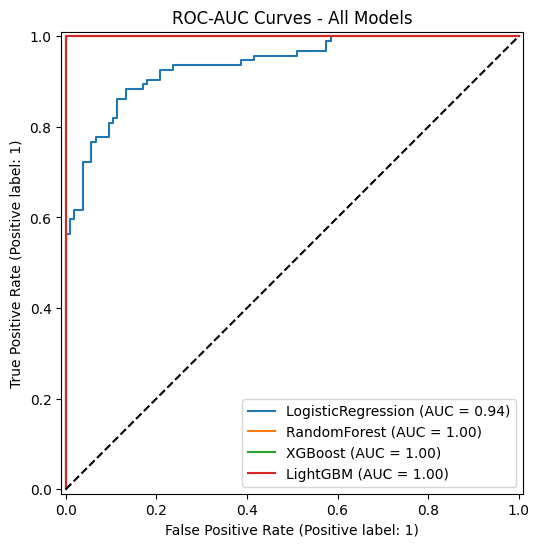


Champion is RandomForest - Saved as RandomForest_champion_model.pkl


In [3]:
#Supervised classification modeling & tuning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import joblib

!pip install xgboost lightgbm -q
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. CREATE DATASE
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'tenure_months': np.random.randint(1, 60, n),
    'monthly_charge': np.random.uniform(20, 100, n),
    'support_tickets': np.random.randint(0, 10, n),
    'plan_type': np.random.choice(['Basic', 'Standard', 'Premium'], n),
    'contract_type': np.random.choice(['Monthly', 'Yearly'], n),
})
df['churned'] = ((df['support_tickets'] > 5) | (df['tenure_months'] < 10)).astype(int)

X = df.drop('churned', axis=1)
y = df['churned']

num_cols = ['tenure_months','monthly_charge','support_tickets']
cat_cols = ['plan_type','contract_type']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. MODELS
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

param_grids = {
    'LogisticRegression': {'model__C': [0.1, 1, 10]},
    'RandomForest': {'model__n_estimators': [100], 'model__max_depth': [5, 10]},
    'XGBoost': {'model__n_estimators': [100], 'model__learning_rate': [0.1]},
    'LightGBM': {'model__n_estimators': [100], 'model__learning_rate': [0.1]}
}

results = []
fig, ax = plt.subplots(figsize=(8,6))
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_estimators = {}

for name in models:
    print(f"\n--- Training {name} ---")
    pipe = Pipeline([('preprocessor', preprocessor), ('model', models[name])])
    grid = GridSearchCV(pipe, param_grids[name], cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_

    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:,1]
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Precision': round(report['1']['precision'],3),
        'Recall': round(report['1']['recall'],3),
        'F1-Score': round(report['1']['f1-score'],3),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba),3)
    })
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)
    print(confusion_matrix(y_test, y_pred))

comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("\n FINAL COMPARISON TABLE")
display(comparison_df)

plt.plot([0,1],[0,1],'k--')
plt.title("ROC-AUC Curves - All Models")
plt.show()

# 3. SAVE CHAMPION
champion_name = comparison_df.iloc[0]['Model']
champion_model = best_estimators[champion_name]
joblib.dump(champion_model, f'{champion_name}_champion_model.pkl')
print(f"\nChampion is {champion_name} - Saved as {champion_name}_champion_model.pkl")